# Task 1

Løser av biharmonisk

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq, fftshift


def biharmonic_solver(X, Y, F, c, mean=0.0):
    """
    Solve the biharmonic equation in 2D using the spectral method.

    Parameters:
        X (ndarray): 2D array of x-coordinates.
        Y (ndarray): 2D array of y-coordinates.
        F (ndarray): 2D array representing the right-hand side of the biharmonic equation.
        c (float): Constant coefficient in the biharmonic equation.
        mean (float, optional): Desired mean value of the solution in case c = 0. Default is 0.0.

    Returns:
        U (ndarray): 2D array representing the solution to the biharmonic equation.
    """
    N, M = F.shape
    L_x = X.max() - X.min()
    L_y = Y.max() - Y.min()
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    k_x = 2*np.pi/L_x * (fftfreq(N, d=dx))
    k_y = 2*np.pi/L_y * (fftfreq(M, d=dy))

    KX, KY = np.meshgrid(k_x, k_y)
    K2 = KX**2 + KY**2
    K4 = (K2**2).T
    K4[0, 0] = 1
    F_hat = (fft2(F))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        U_hat = np.where(K4 + c > 1e-10, F_hat / (K4 + c), 0.0)

    # Compute inverse Fourier transform
    U = np.real((ifft2(U_hat)))

    # Enforce mean if c = 0
    if c == 0:
        U -= np.mean(U) - mean
    return U

In [88]:
import sympy as sp

x, y, c = sp.symbols('x y c')

u1 = sp.sin(8 * (x - 1)) * sp.cos(4 * y)
laplacian_u1 = sp.diff(u1, x, 2) + sp.diff(u1, y, 2)
biharmonic_u1 = sp.diff(laplacian_u1, x, 2) + sp.diff(laplacian_u1, y, 2)

F1 = biharmonic_u1  + c * u1
F1_simplified = sp.simplify(F1)
sp.pprint(F1_simplified)
F1_func = sp.lambdify((x, y, c), F1_simplified, "numpy")

(c + 6400)⋅sin(8⋅x - 8)⋅cos(4⋅y)


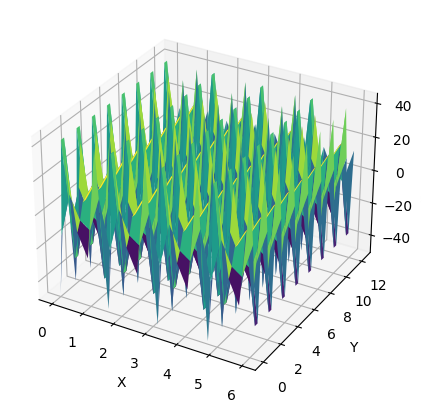

In [182]:
def U1_exact(x, y):
    return np.sin(8*(x-1))*np.cos(4*y)

c = 1
N = 20
x, y = np.linspace(0, 2*np.pi, N, endpoint=False), np.linspace(0, 4*np.pi, 2*N, endpoint=False)
X, Y = np.meshgrid(x, y)
F1_numeric = lambda X, Y: F1_func(X, Y, c)

U1_numeric = biharmonic_solver(X, Y, F1_numeric(X, Y), c)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, U1_numeric, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U1_numeric')
plt.show()

In [ ]:
def U2_exact(x, y):
    return np.exp(np.sin(x)**2 + np.cos(2*y))